# Step 3 — Data Cleaning

In [1]:
import pandas as pd
import numpy as np 

In [2]:
df = pd.read_csv("UK-HPI-full-file-2025-12.csv")

In [3]:
df.head()

,Date,RegionName,AreaCode,AveragePrice,Index,IndexSA,1m%Change,12m%Change,AveragePriceSA,SalesVolume,...,NewPrice,NewIndex,New1m%Change,New12m%Change,NewSalesVolume,OldPrice,OldIndex,Old1m%Change,Old12m%Change,OldSalesVolume
0,01/01/2004,Aberdeenshire,S12000034,84638,41.1,NaN,NaN,NaN,NaN,388.0,...,112843.0,40.7,NaN,NaN,103.0,81273.0,41.0,NaN,NaN,285.0
1,01/02/2004,Aberdeenshire,S12000034,84623,41.1,NaN,0.0,NaN,NaN,326.0,...,113061.0,40.8,0.2,NaN,107.0,81194.0,40.9,-0.1,NaN,219.0
2,01/03/2004,Aberdeenshire,S12000034,86536,42.1,NaN,2.3,NaN,NaN,453.0,...,115218.0,41.6,1.9,NaN,140.0,83137.0,41.9,2.4,NaN,313.0
3,01/04/2004,Aberdeenshire,S12000034,87373,42.5,NaN,1.0,NaN,NaN,571.0,...,115247.0,41.6,0.0,NaN,180.0,84241.0,42.5,1.3,NaN,391.0
4,01/05/2004,Aberdeenshire,S12000034,89493,43.5,NaN,2.4,NaN,NaN,502.0,...,117377.0,42.4,1.8,NaN,167.0,86466.0,43.6,2.6,NaN,335.0


In [4]:
df_clean = df.copy()

In [5]:
df.shape
df_clean.shape

(149085, 54)

In [6]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149085 entries, 0 to 149084
Data columns (total 54 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   Date                    149085 non-null  object 
 1   RegionName              149085 non-null  object 
 2   AreaCode                149085 non-null  object 
 3   AveragePrice            149085 non-null  int64  
 4   Index                   149085 non-null  float64
 5   IndexSA                 5244 non-null    float64
 6   1m%Change               148632 non-null  float64
 7   12m%Change              144225 non-null  float64
 8   AveragePriceSA          5244 non-null    float64
 9   SalesVolume             144618 non-null  float64
 10  DetachedPrice           142284 non-null  float64
 11  DetachedIndex           142284 non-null  float64
 12  Detached1m%Change       141889 non-null  float64
 13  Detached12m%Change      137568 non-null  float64
 14  SemiDetachedPrice   

In [7]:
df_clean["Date"] = pd.to_datetime(
    df_clean["Date"],
    dayfirst=True,
    errors="coerce"
)

In [8]:
df_clean["Date"].dtype

dtype('<M8[ns]')

In [9]:
df_clean["Date"].isna().sum()

np.int64(0)

In [10]:
df_clean["Date"].min(), df_clean["Date"].max()

(Timestamp('1968-04-01 00:00:00'), Timestamp('2025-12-01 00:00:00'))

In [11]:
df_clean["Date"].dt.year.nunique()

58

In [12]:
df_clean["Date"].dt.year.unique()

array([2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014,
       2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025,
       1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 1968, 1969,
       1970, 1971, 1972, 1973, 1974, 1975, 1976, 1977, 1978, 1979, 1980,
       1981, 1982, 1983, 1984, 1985, 1986, 1987, 1988, 1989, 1990, 1991,
       1992, 1993, 1994], dtype=int32)

In [13]:
missing = df_clean.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

missing

IndexSA                   143841
AveragePriceSA            143841
FOO12m%Change              87933
Mortgage12m%Change         87933
Cash12m%Change             87933
FTB12m%Change              87537
CashSalesVolume            84017
MortgageSalesVolume        84015
Mortgage1m%Change          83621
Cash1m%Change              83621
FOO1m%Change               83621
MortgagePrice              83229
CashIndex                  83229
FOOIndex                   83229
CashPrice                  83229
MortgageIndex              83229
FOOPrice                   83229
FTB1m%Change               83225
FTBIndex                   82833
FTBPrice                   82833
New12m%Change              12149
Old12m%Change              11945
Detached12m%Change         11517
SemiDetached12m%Change     11517
Terraced12m%Change         11418
Flat12m%Change             11157
NewSalesVolume             10602
New1m%Change                7817
Old1m%Change                7613
NewIndex                    7421
NewPrice  

In [14]:
missing_percentage = (
    df_clean.isnull().sum() / len(df_clean) * 100
).sort_values(ascending=False)

missing_percentage[missing_percentage > 0]

IndexSA                   96.482544
AveragePriceSA            96.482544
Mortgage12m%Change        58.981789
FOO12m%Change             58.981789
Cash12m%Change            58.981789
FTB12m%Change             58.716169
CashSalesVolume           56.355099
MortgageSalesVolume       56.353758
Cash1m%Change             56.089479
Mortgage1m%Change         56.089479
FOO1m%Change              56.089479
FOOIndex                  55.826542
MortgageIndex             55.826542
CashPrice                 55.826542
MortgagePrice             55.826542
CashIndex                 55.826542
FOOPrice                  55.826542
FTB1m%Change              55.823859
FTBPrice                  55.560922
FTBIndex                  55.560922
New12m%Change              8.149042
Old12m%Change              8.012208
SemiDetached12m%Change     7.725123
Detached12m%Change         7.725123
Terraced12m%Change         7.658718
Flat12m%Change             7.483650
NewSalesVolume             7.111379
New1m%Change               5

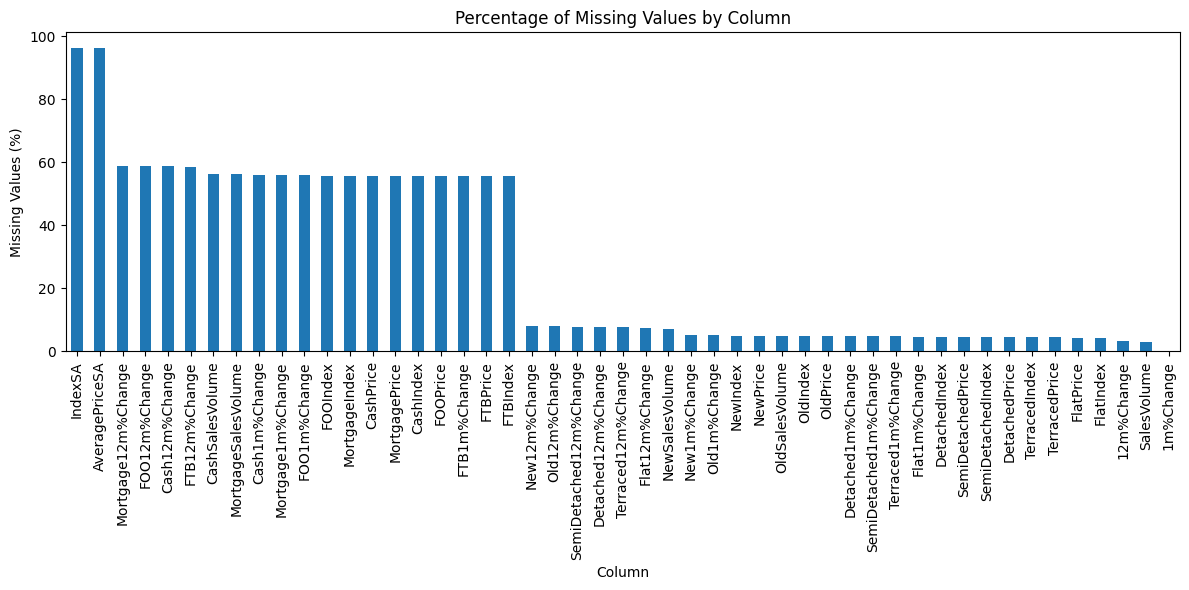

In [15]:
import matplotlib.pyplot as plt

missing_percentage = (
    df_clean.isnull().mean() * 100
).sort_values(ascending=False)

missing_percentage = missing_percentage[missing_percentage > 0]

plt.figure(figsize=(12, 6))
missing_percentage.plot(kind="bar")
plt.title("Percentage of Missing Values by Column")
plt.xlabel("Column")
plt.ylabel("Missing Values (%)")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [16]:
df_clean.duplicated().sum()

np.int64(0)

In [17]:
df_clean.duplicated(
    subset=["RegionName", "Date"]
).sum()

np.int64(0)

In [18]:
df_clean["RegionName"].nunique()

405

In [19]:
df_clean["RegionName"].unique()

array(['Aberdeenshire', 'Adur', 'Amber Valley', 'Angus',
       'Antrim and Newtownabbey', 'Ards and North Down',
       'Argyll and Bute', 'Armagh City Banbridge and Craigavon', 'Arun',
       'Ashfield', 'Ashford', 'Babergh', 'Barking and Dagenham', 'Barnet',
       'Barnsley', 'Basildon', 'Basingstoke and Deane', 'Bassetlaw',
       'Bath and North East Somerset', 'Bedford', 'Belfast', 'Bexley',
       'Birmingham', 'Blaby', 'Blackburn with Darwen', 'Blackpool',
       'Blaenau Gwent', 'Bolsover', 'Bolton', 'Boston',
       'Bournemouth Christchurch and Poole', 'Bracknell Forest',
       'Bradford', 'Braintree', 'Breckland', 'Brent', 'Brentwood',
       'Bridgend', 'Brighton and Hove', 'Broadland', 'Bromley',
       'Bromsgrove', 'Broxbourne', 'Broxtowe', 'Buckinghamshire',
       'Burnley', 'Bury', 'Caerphilly', 'Calderdale', 'Cambridge',
       'Cambridgeshire', 'Camden', 'Cannock Chase', 'Canterbury',
       'Cardiff', 'Carmarthenshire', 'Castle Point',
       'Causeway Coast and

In [20]:
df_clean["RegionName"].value_counts().head(30)

RegionName
Yorkshire and The Humber              693
United Kingdom                        693
East Midlands                         693
England                               693
West Midlands Region                  693
Wales                                 693
London                                693
Northern Ireland                      693
Scotland                              693
South West                            693
East of England                       405
North East                            405
South East                            405
West Suffolk                          372
West Oxfordshire                      372
West Northamptonshire                 372
Bournemouth Christchurch and Poole    372
Bracknell Forest                      372
Bradford                              372
Braintree                             372
Breckland                             372
Brent                                 372
Wealden                               372
Welwyn Hatfield        

In [21]:
df_clean["AreaCode"].nunique()

405

In [22]:
df_clean[["RegionName", "AreaCode"]].drop_duplicates().head(30)

,RegionName,AreaCode
0,Aberdeenshire,S12000034
264,Adur,E07000223
636,Amber Valley,E07000032
1008,Angus,S12000041
1272,Antrim and Newtownabbey,N09000001
1524,Ards and North Down,N09000011
1776,Argyll and Bute,S12000035
2040,Armagh City Banbridge and Craigavon,N09000002
2292,Arun,E07000224
2664,Ashfield,E07000170


In [23]:
df_clean[
    [
        "AveragePrice",
        "Index",
        "1m%Change",
        "12m%Change",
        "SalesVolume"
    ]
].describe()

,AveragePrice,Index,1m%Change,12m%Change,SalesVolume
count,1.490850e+05,149085.000000,148632.000000,144225.000000,144618.000000
mean,1.831012e+05,59.835763,0.526866,6.100826,1252.600105
std,1.311841e+05,26.619737,1.934405,8.622357,7707.191260
min,2.553000e+03,0.800000,-30.300000,-35.800000,2.000000
25%,1.005410e+05,38.200000,-0.500000,1.100000,140.000000
50%,1.547560e+05,61.000000,0.500000,5.100000,215.000000
75%,2.301380e+05,80.300000,1.400000,10.100000,376.000000
max,1.656986e+06,153.100000,35.300000,98.400000,183609.000000


In [24]:
(df_clean["AveragePrice"] < 0).sum()

np.int64(0)

In [25]:
(df_clean["SalesVolume"] < 0).sum()

np.int64(0)

In [26]:
(df_clean["Index"] < 0).sum()

np.int64(0)

In [27]:
df_clean[
    ["1m%Change", "12m%Change"]
].describe()

,1m%Change,12m%Change
count,148632.000000,144225.000000
mean,0.526866,6.100826
std,1.934405,8.622357
min,-30.300000,-35.800000
25%,-0.500000,1.100000
50%,0.500000,5.100000
75%,1.400000,10.100000
max,35.300000,98.400000


In [28]:
df_clean[
    ["1m%Change", "12m%Change"]
].sort_values("12m%Change").head(10)

,1m%Change,12m%Change
78492,-17.8,-35.8
78493,-17.8,-35.8
78494,-17.8,-35.8
71964,-7.1,-32.8
71965,-7.1,-32.8
71966,-7.1,-32.8
48339,-15.2,-32.5
48340,-15.2,-32.5
48341,-15.2,-32.5
2088,-10.0,-32.2


In [29]:
df_clean[
    ["1m%Change", "12m%Change"]
].sort_values("12m%Change", ascending=False).head(10)

,1m%Change,12m%Change
80977,-6.6,98.4
80978,11.5,89.4
26987,-2.2,85.9
26986,31.3,83.7
80976,14.4,76.3
26988,-9.7,63.6
113639,10.3,63.0
113638,10.3,63.0
113637,10.3,63.0
2064,13.8,61.9


In [30]:
df_clean["Year"] = df_clean["Date"].dt.year

In [31]:
df_clean["Month"] = df_clean["Date"].dt.month

In [32]:
df_clean["Quarter"] = df_clean["Date"].dt.quarter

In [33]:
df_clean["YearMonth"] = df_clean["Date"].dt.to_period("M")

In [34]:
df_clean[
    ["Date", "Year", "Month", "Quarter", "YearMonth"]
].head()

,Date,Year,Month,Quarter,YearMonth
0,2004-01-01,2004,1,1,2004-01
1,2004-02-01,2004,2,1,2004-02
2,2004-03-01,2004,3,1,2004-03
3,2004-04-01,2004,4,2,2004-04
4,2004-05-01,2004,5,2,2004-05


In [35]:
print("Rows:", df_clean.shape[0])
print("Columns:", df_clean.shape[1])
print("Duplicate rows:", df_clean.duplicated().sum())
print("Duplicate Region + Date:", 
      df_clean.duplicated(subset=["RegionName", "Date"]).sum())
print("Missing Date:", df_clean["Date"].isna().sum())
print("Unique regions:", df_clean["RegionName"].nunique())
print("Date range:", df_clean["Date"].min(), "to", df_clean["Date"].max())

Rows: 149085
Columns: 58
Duplicate rows: 0
Duplicate Region + Date: 0
Missing Date: 0
Unique regions: 405
Date range: 1968-04-01 00:00:00 to 2025-12-01 00:00:00


# 3.17 — Inspect RegionName and AreaCode

In [36]:
df_clean[["RegionName", "AreaCode"]].drop_duplicates().head(50)

,RegionName,AreaCode
0,Aberdeenshire,S12000034
264,Adur,E07000223
636,Amber Valley,E07000032
1008,Angus,S12000041
1272,Antrim and Newtownabbey,N09000001
1524,Ards and North Down,N09000011
1776,Argyll and Bute,S12000035
2040,Armagh City Banbridge and Craigavon,N09000002
2292,Arun,E07000224
2664,Ashfield,E07000170


In [37]:
df_clean[["RegionName", "AreaCode"]].drop_duplicates().shape

(405, 2)

# 3.18 — Check whether each region has one AreaCode

In [38]:
region_area_codes = (
    df_clean.groupby("RegionName")["AreaCode"]
    .nunique()
    .sort_values(ascending=False)
)

region_area_codes.head(20)

RegionName
Aberdeenshire                          1
Adur                                   1
Amber Valley                           1
Angus                                  1
Antrim and Newtownabbey                1
Ards and North Down                    1
Argyll and Bute                        1
Armagh City Banbridge and Craigavon    1
Arun                                   1
Ashfield                               1
Ashford                                1
Babergh                                1
Barking and Dagenham                   1
Barnet                                 1
Barnsley                               1
Basildon                               1
Basingstoke and Deane                  1
Bassetlaw                              1
Bath and North East Somerset           1
Bedford                                1
Name: AreaCode, dtype: int64

In [39]:
region_area_codes[region_area_codes > 1]

Series([], Name: AreaCode, dtype: int64)

# 3.19 — Examine the geographic hierarchy

In [40]:
region_counts = df_clean["RegionName"].value_counts()

region_counts.head(30)

RegionName
Yorkshire and The Humber              693
United Kingdom                        693
East Midlands                         693
England                               693
West Midlands Region                  693
Wales                                 693
London                                693
Northern Ireland                      693
Scotland                              693
South West                            693
East of England                       405
North East                            405
South East                            405
West Suffolk                          372
West Oxfordshire                      372
West Northamptonshire                 372
Bournemouth Christchurch and Poole    372
Bracknell Forest                      372
Bradford                              372
Braintree                             372
Breckland                             372
Brent                                 372
Wealden                               372
Welwyn Hatfield        

In [41]:
region_date_summary = (
    df_clean.groupby("RegionName")["Date"]
    .agg(["min", "max", "count"])
    .sort_values("count", ascending=False)
)

region_date_summary.head(30)

,min,max,count
RegionName,,,
Yorkshire and The Humber,1968-04-01,2025-12-01,693
United Kingdom,1968-04-01,2025-12-01,693
East Midlands,1968-04-01,2025-12-01,693
England,1968-04-01,2025-12-01,693
West Midlands Region,1968-04-01,2025-12-01,693
Wales,1968-04-01,2025-12-01,693
London,1968-04-01,2025-12-01,693
Northern Ireland,1968-04-01,2025-12-01,693
Scotland,1968-04-01,2025-12-01,693


 # 3.20 — Find the earliest date for each region

In [42]:
region_date_summary.sort_values("min").head(30)

,min,max,count
RegionName,,,
Yorkshire and The Humber,1968-04-01,2025-12-01,693
United Kingdom,1968-04-01,2025-12-01,693
East Midlands,1968-04-01,2025-12-01,693
England,1968-04-01,2025-12-01,693
West Midlands Region,1968-04-01,2025-12-01,693
Wales,1968-04-01,2025-12-01,693
London,1968-04-01,2025-12-01,693
Northern Ireland,1968-04-01,2025-12-01,693
Scotland,1968-04-01,2025-12-01,693


In [43]:
region_date_summary.sort_values("min", ascending=False).head(30)

,min,max,count
RegionName,,,
Belfast,2005-01-01,2025-12-01,252
Mid and East Antrim,2005-01-01,2025-12-01,252
Ards and North Down,2005-01-01,2025-12-01,252
Armagh City Banbridge and Craigavon,2005-01-01,2025-12-01,252
Fermanagh and Omagh,2005-01-01,2025-12-01,252
Lisburn and Castlereagh,2005-01-01,2025-12-01,252
Antrim and Newtownabbey,2005-01-01,2025-12-01,252
Mid Ulster,2005-01-01,2025-12-01,252
Newry Mourne and Down,2005-01-01,2025-12-01,252


# 3.21 — Identify geographic levels

In [44]:
full_history_regions = region_counts[region_counts == 693].index

full_history_regions.tolist()

['Yorkshire and The Humber',
 'United Kingdom',
 'East Midlands',
 'England',
 'West Midlands Region',
 'Wales',
 'London',
 'Northern Ireland',
 'Scotland',
 'South West']

In [45]:
df_clean[
    df_clean["RegionName"].isin(full_history_regions)
][["RegionName", "AreaCode"]].drop_duplicates().sort_values("RegionName")

,RegionName,AreaCode
40020,East Midlands,E12000004
44358,England,E92000001
72543,London,E12000007
90597,Northern Ireland,N92000002
104730,Scotland,S92000003
113580,South West,E12000009
130533,United Kingdom,K02000001
132714,Wales,W92000004
139515,West Midlands Region,E12000005
148392,Yorkshire and The Humber,E12000003


# 3.22 — Why we're doing this

Our eventual Power BI dashboard should probably have a filter such as:

Geographic Level

UK
Country
Region
Local Authority

Then users can choose the appropriate level.

For example:

UK-level analysis

We might use:

United Kingdom
Regional analysis

We might use:

London
South East
South West
East Midlands
West Midlands
North West
North East
Yorkshire and The Humber
East of England
Local-authority analysis

We might use:

Brent
Bradford
Braintree
Breckland
West Suffolk
...

This prevents us from accidentally comparing England with Brent in the same ranking.

# 3.23 — Check the number of observations by region

In [46]:
region_summary = (
    df_clean.groupby("RegionName")
    .agg(
        Observations=("Date", "count"),
        StartDate=("Date", "min"),
        EndDate=("Date", "max"),
        AvgPrice=("AveragePrice", "mean")
    )
    .sort_values("Observations", ascending=False)
)

region_summary.head(30)

,Observations,StartDate,EndDate,AvgPrice
RegionName,,,,
Yorkshire and The Humber,693,1968-04-01,2025-12-01,72579.138528
United Kingdom,693,1968-04-01,2025-12-01,96301.174603
East Midlands,693,1968-04-01,2025-12-01,83424.584416
England,693,1968-04-01,2025-12-01,101809.043290
West Midlands Region,693,1968-04-01,2025-12-01,86024.834055
Wales,693,1968-04-01,2025-12-01,72692.079365
London,693,1968-04-01,2025-12-01,196886.548341
Northern Ireland,693,1968-04-01,2025-12-01,69698.243867
Scotland,693,1968-04-01,2025-12-01,68818.229437


# 3.24 — Check whether every region has continuous monthly data

In [47]:
def check_missing_months(group):
    dates = group["Date"].sort_values()
    
    expected = pd.date_range(
        start=dates.min(),
        end=dates.max(),
        freq="MS"
    )
    
    return len(expected) - len(dates)

In [48]:
missing_months = (
    df_clean.groupby("RegionName")
    .apply(check_missing_months)
    .sort_values(ascending=False)
)

missing_months.head(20)

C:\Users\Sweet\AppData\Local\Temp\ipykernel_19388\2411406368.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(check_missing_months)


RegionName
Aberdeenshire                          0
Adur                                   0
Amber Valley                           0
Angus                                  0
Antrim and Newtownabbey                0
Ards and North Down                    0
Argyll and Bute                        0
Armagh City Banbridge and Craigavon    0
Arun                                   0
Ashfield                               0
Ashford                                0
Babergh                                0
Barking and Dagenham                   0
Barnet                                 0
Barnsley                               0
Basildon                               0
Basingstoke and Deane                  0
Bassetlaw                              0
Bath and North East Somerset           0
Bedford                                0
dtype: int64

# 3.25 — Create a simple data-quality summary

In [49]:
print("Total rows:", len(df_clean))
print("Total regions:", df_clean["RegionName"].nunique())
print("Total area codes:", df_clean["AreaCode"].nunique())
print("Duplicate rows:", df_clean.duplicated().sum())
print("Duplicate Region + Date:", 
      df_clean.duplicated(["RegionName", "Date"]).sum())
print("Invalid dates:", df_clean["Date"].isna().sum())

Total rows: 149085
Total regions: 405
Total area codes: 405
Duplicate rows: 0
Duplicate Region + Date: 0
Invalid dates: 0


# 3.26 — Create GeoLevel

In [50]:
# Define geographic levels

countries = [
    "England",
    "Scotland",
    "Wales",
    "Northern Ireland"
]

regions = [
    "North East",
    "North West",
    "Yorkshire and The Humber",
    "East Midlands",
    "West Midlands Region",
    "East of England",
    "London",
    "South East",
    "South West"
]

aggregates = [
    "England and Wales",
    "Great Britain"
]

df_clean["GeoLevel"] = "Local Authority"

df_clean.loc[
    df_clean["RegionName"] == "United Kingdom",
    "GeoLevel"
] = "UK"

df_clean.loc[
    df_clean["RegionName"].isin(countries),
    "GeoLevel"
] = "Country"

df_clean.loc[
    df_clean["RegionName"].isin(regions),
    "GeoLevel"
] = "Region"

df_clean.loc[
    df_clean["RegionName"].isin(aggregates),
    "GeoLevel"
] = "Aggregate"


In [51]:
df_clean["GeoLevel"].value_counts()

GeoLevel
Local Authority    139932
Region               5052
Country              2772
UK                    693
Aggregate             636
Name: count, dtype: int64

# 3.27 — Check our classification

In [52]:
df_clean[
    ["RegionName", "AreaCode", "GeoLevel"]
].drop_duplicates().sort_values(
    ["GeoLevel", "RegionName"]
).head(50)

,RegionName,AreaCode,GeoLevel
45051,England and Wales,K04000001,Aggregate
52527,Great Britain,K03000001,Aggregate
44358,England,E92000001,Country
90597,Northern Ireland,N92000002,Country
104730,Scotland,S92000003,Country
132714,Wales,W92000004,Country
0,Aberdeenshire,S12000034,Local Authority
264,Adur,E07000223,Local Authority
636,Amber Valley,E07000032,Local Authority
1008,Angus,S12000041,Local Authority


In [53]:
df_clean[
    df_clean["GeoLevel"] == "Region"
][
    ["RegionName", "AreaCode"]
].drop_duplicates().sort_values("RegionName")

,RegionName,AreaCode
40020,East Midlands,E12000004
42465,East of England,E12000006
72543,London,E12000007
85092,North East,E12000001
89481,North West,E12000002
109563,South East,E12000008
113580,South West,E12000009
139515,West Midlands Region,E12000005
148392,Yorkshire and The Humber,E12000003


# 3.28 — Verify that nothing important was accidentally classified incorrectly

In [54]:
df_clean[
    df_clean["GeoLevel"].isin(["UK", "Country", "Region", "Aggregate"])
][
    ["RegionName", "AreaCode", "GeoLevel"]
].drop_duplicates()


,RegionName,AreaCode,GeoLevel
40020,East Midlands,E12000004,Region
42465,East of England,E12000006,Region
44358,England,E92000001,Country
45051,England and Wales,K04000001,Aggregate
52527,Great Britain,K03000001,Aggregate
72543,London,E12000007,Region
85092,North East,E12000001,Region
89481,North West,E12000002,Region
90597,Northern Ireland,N92000002,Country
104730,Scotland,S92000003,Country


# 3.29 — Our main geographical analysis

12 UK regions/countries

For geographic comparison:

North East
North West
Yorkshire and The Humber
East Midlands
West Midlands Region
East of England
London
South East
South West
Scotland
Wales
Northern Ireland

# 3.30 -  investigate the missing months

In [55]:
missing_months.head(20)

RegionName
Aberdeenshire                          0
Adur                                   0
Amber Valley                           0
Angus                                  0
Antrim and Newtownabbey                0
Ards and North Down                    0
Argyll and Bute                        0
Armagh City Banbridge and Craigavon    0
Arun                                   0
Ashfield                               0
Ashford                                0
Babergh                                0
Barking and Dagenham                   0
Barnet                                 0
Barnsley                               0
Basildon                               0
Basingstoke and Deane                  0
Bassetlaw                              0
Bath and North East Somerset           0
Bedford                                0
dtype: int64

In [56]:
missing_months.value_counts().sort_index()

0    405
Name: count, dtype: int64

# 3.33 — Check coverage by geographic level

In [57]:
df_clean.groupby("GeoLevel")["RegionName"].nunique()

GeoLevel
Aggregate            2
Country              4
Local Authority    389
Region               9
UK                   1
Name: RegionName, dtype: int64

In [58]:
df_clean.groupby("GeoLevel").agg(
    UniqueAreas=("RegionName", "nunique"),
    StartDate=("Date", "min"),
    EndDate=("Date", "max"),
    Rows=("Date", "count")
)

,UniqueAreas,StartDate,EndDate,Rows
GeoLevel,,,,
Aggregate,2,1995-01-01,2025-12-01,636
Country,4,1968-04-01,2025-12-01,2772
Local Authority,389,1995-01-01,2025-12-01,139932
Region,9,1968-04-01,2025-12-01,5052
UK,1,1968-04-01,2025-12-01,693


# 3.34 — Missing Value Analysis

Now that `GeoLevel` is in place, we go column-by-column through everything that has missing values and decide, with evidence rather than guesswork:

- which columns are **safe to use** for the main analysis (low missingness, or missingness that is fully explained by dataset structure)
- which columns are **usable but limited** (real data, just only available for part of the time range)
- which columns we **exclude** entirely (too sparse or not actually a Local-Authority-level field)


### 3.34.1 — Rebuild the missing value table with counts and percentages


In [59]:
missing_summary = pd.DataFrame({
    "MissingCount": df_clean.isnull().sum(),
    "MissingPercent": (df_clean.isnull().mean() * 100).round(2)
})

missing_summary = missing_summary[missing_summary["MissingCount"] > 0]
missing_summary = missing_summary.sort_values("MissingPercent", ascending=False)

missing_summary

,MissingCount,MissingPercent
IndexSA,143841,96.48
AveragePriceSA,143841,96.48
FOO12m%Change,87933,58.98
Mortgage12m%Change,87933,58.98
Cash12m%Change,87933,58.98
FTB12m%Change,87537,58.72
CashSalesVolume,84017,56.36
MortgageSalesVolume,84015,56.35
Mortgage1m%Change,83621,56.09
Cash1m%Change,83621,56.09


### 3.34.2 — Investigate the two near-total columns: `AveragePriceSA` / `IndexSA`

These are missing ~96% of the time overall, which is suspicious enough that we shouldn't just accept a "high missing %" label — we need to know *why*.

In [60]:
sa_populated_regions = df_clean.loc[
    df_clean["AveragePriceSA"].notna(), "RegionName"
].unique()

sa_populated_regions

array(['East Midlands', 'East of England', 'England', 'England and Wales',
       'Great Britain', 'London', 'North East', 'North West', 'Scotland',
       'South East', 'South West', 'United Kingdom', 'Wales',
       'West Midlands Region', 'Yorkshire and The Humber'], dtype=object)

`AveragePriceSA` / `IndexSA` (seasonally adjusted price/index) are only ever populated for a small set of national/regional aggregates — the 9 English regions, the 4 UK countries, the UK total, and two extra pseudo-national rows, `England and Wales` and `Great Britain`.

That last part is itself a data-quality finding: `England and Wales` and `Great Britain` are currently tagged `GeoLevel = "Local Authority"` because they aren't in our `countries` / `regions` lists — but they're clearly national aggregates, not local authorities. Let's confirm that before deciding anything about the SA columns.

In [61]:
df_clean[
    df_clean["RegionName"].isin(["England and Wales", "Great Britain"])
][["RegionName", "AreaCode", "GeoLevel"]].drop_duplicates()

,RegionName,AreaCode,GeoLevel
45051,England and Wales,K04000001,Aggregate
52527,Great Britain,K03000001,Aggregate


Confirmed — both are aggregate geographic areas rather than countries or local authorities. We'll classify `England and Wales` and `Great Britain` as `Aggregate` so the hierarchy remains analytically clear.


In [62]:
df_clean.loc[
    df_clean["RegionName"].isin(["England and Wales", "Great Britain"]),
    "GeoLevel"
] = "Aggregate"

df_clean["GeoLevel"].value_counts()


GeoLevel
Local Authority    139932
Region               5052
Country              2772
UK                    693
Aggregate             636
Name: count, dtype: int64

Even after that fix, `AveragePriceSA` / `IndexSA` are structurally a national/regional-aggregate-only field — no Local Authority ever has a value. Since our analysis is built around comparing Local Authorities as well as regions, these two columns aren't usable at the grain most of the dataset lives at.

**Decision: drop `AveragePriceSA` and `IndexSA` from the analysis columns.**

### 3.34.3 — Investigate the Cash / Mortgage / FTB / FOO groups (~55–59% missing)

These columns (buyer-type breakdowns: Cash buyers, Mortgaged buyers, First-Time Buyers, Former Owner-Occupiers) are missing over half the time. Before excluding them, check whether that's random missingness or simply because HM Land Registry didn't start publishing these breakdowns until partway through the series.

In [63]:
buyer_type_cols = [
    "FTBPrice", "FTBIndex", "FTB1m%Change", "FTB12m%Change",
    "CashPrice", "CashIndex", "Cash1m%Change", "Cash12m%Change", "CashSalesVolume",
    "MortgagePrice", "MortgageIndex", "Mortgage1m%Change", "Mortgage12m%Change", "MortgageSalesVolume",
    "FOOPrice", "FOOIndex", "FOO1m%Change", "FOO12m%Change"
]

first_valid_dates = df_clean[buyer_type_cols].apply(
    lambda col: df_clean.loc[col.notna(), "Date"].min()
)

first_valid_dates.sort_values()

FTBPrice              2011-01-01
FTBIndex              2011-01-01
FTB1m%Change          2011-02-01
FOOIndex              2012-01-01
FOOPrice              2012-01-01
MortgageSalesVolume   2012-01-01
MortgageIndex         2012-01-01
MortgagePrice         2012-01-01
CashSalesVolume       2012-01-01
CashIndex             2012-01-01
CashPrice             2012-01-01
FTB12m%Change         2012-01-01
Cash1m%Change         2012-02-01
Mortgage1m%Change     2012-02-01
FOO1m%Change          2012-02-01
Cash12m%Change        2013-01-01
Mortgage12m%Change    2013-01-01
FOO12m%Change         2013-01-01
dtype: datetime64[ns]

In [64]:
# If the missingness is purely a "not published yet" issue, missing % should
# collapse to ~0 once we only look at dates on/after each column's own start date.

for col in ["FTBPrice", "CashPrice", "MortgagePrice", "FOOPrice"]:
    start = df_clean.loc[df_clean[col].notna(), "Date"].min()
    after_start = df_clean[df_clean["Date"] >= start]
    pct_missing_after_start = after_start[col].isna().mean() * 100
    print(f"{col:15s} starts {start.date()} | missing % from that date onward: {pct_missing_after_start:.2f}%")

FTBPrice        starts 2011-01-01 | missing % from that date onward: 9.12%
CashPrice       starts 2012-01-01 | missing % from that date onward: 3.21%
MortgagePrice   starts 2012-01-01 | missing % from that date onward: 3.21%
FOOPrice        starts 2012-01-01 | missing % from that date onward: 3.21%


Confirmed — once we're past each column's publication start date (2011 for FTB, 2012 for Cash/Mortgage/FOO), missingness drops to a low single-digit percentage, consistent with the same reporting gaps we see in the core columns. The high overall percentage is a **time-window artefact**, not a data-quality problem.

**Decision: keep the buyer-type columns, but flag them as "recent-data-only" — any trend analysis using them should either start from 2011/2012, or explicitly note the shorter window.**

### 3.34.4 — Investigate the mid-range group (~4–8% missing): property types, New/Old, SalesVolume, 12m%Change

In [65]:
mid_missing_cols = [
    "SalesVolume", "12m%Change", "1m%Change",
    "DetachedPrice", "SemiDetachedPrice", "TerracedPrice", "FlatPrice",
    "DetachedIndex", "SemiDetachedIndex", "TerracedIndex", "FlatIndex",
    "NewPrice", "OldPrice", "NewIndex", "OldIndex"
]

first_valid_dates_mid = df_clean[mid_missing_cols].apply(
    lambda col: df_clean.loc[col.notna(), "Date"].min()
)

first_valid_dates_mid.sort_values()

1m%Change           1968-07-01
12m%Change          1969-04-01
SalesVolume         1995-01-01
DetachedPrice       1995-01-01
SemiDetachedPrice   1995-01-01
TerracedPrice       1995-01-01
FlatPrice           1995-01-01
DetachedIndex       1995-01-01
SemiDetachedIndex   1995-01-01
TerracedIndex       1995-01-01
FlatIndex           1995-01-01
NewPrice            1995-01-01
OldPrice            1995-01-01
NewIndex            1995-01-01
OldIndex            1995-01-01
dtype: datetime64[ns]

In [66]:
# Same check: does missingness collapse once we're past 1995 (when these
# breakdowns start) and are we just seeing normal reporting gaps by region?

for col in ["SalesVolume", "DetachedPrice", "NewPrice"]:
    after_1995 = df_clean[df_clean["Date"] >= "1995-01-01"]
    pct_missing = after_1995[col].isna().mean() * 100
    print(f"{col:15s} missing % from 1995 onward: {pct_missing:.2f}%")

print()
print("Missing % by GeoLevel, from 1995 onward:")
after_1995 = df_clean[df_clean["Date"] >= "1995-01-01"]
print(
    after_1995.groupby("GeoLevel")[["SalesVolume", "DetachedPrice", "NewPrice"]]
    .apply(lambda g: g.isna().mean() * 100)
)

SalesVolume     missing % from 1995 onward: 0.79%
DetachedPrice   missing % from 1995 onward: 2.40%
NewPrice        missing % from 1995 onward: 2.82%

Missing % by GeoLevel, from 1995 onward:
                 SalesVolume  DetachedPrice   NewPrice
GeoLevel                                              
Aggregate           0.628931       0.000000   0.628931
Country            15.860215      15.322581  15.860215
Local Authority     0.555984       2.246806   2.667010
Region              0.537634       0.000000   0.537634
UK                 32.795699      32.258065  32.795699


Same pattern as the buyer-type columns, just starting earlier (1995 instead of 2011/2012): these breakdowns weren't published before 1995, and once we're past that date the missingness is low almost everywhere. The one exception is `UK` / `Country` / `Region` rows, which have noticeably higher missing % than `Local Authority` — likely because national/regional aggregates for some of these breakdowns weren't calculated for every month even after 1995.

**Decision: keep this whole group for the main analysis.** For Local Authority–level work they're effectively complete from 1995 onward; for national/regional-level work, expect some additional gaps and handle with `dropna()` on a per-analysis basis rather than a blanket rule.

### 3.34.5 — Final classification

In [67]:
columns_drop = ["AveragePriceSA", "IndexSA"]

columns_recent_only = [
    "FTBPrice", "FTBIndex", "FTB1m%Change", "FTB12m%Change",
    "CashPrice", "CashIndex", "Cash1m%Change", "Cash12m%Change", "CashSalesVolume",
    "MortgagePrice", "MortgageIndex", "Mortgage1m%Change", "Mortgage12m%Change", "MortgageSalesVolume",
    "FOOPrice", "FOOIndex", "FOO1m%Change", "FOO12m%Change"
]

columns_available_from_1995 = [
    "AveragePrice", "Index", "1m%Change", "12m%Change", "SalesVolume",
    "DetachedPrice", "SemiDetachedPrice", "TerracedPrice", "FlatPrice",
    "DetachedIndex", "SemiDetachedIndex", "TerracedIndex", "FlatIndex",
    "NewPrice", "OldPrice", "NewIndex", "OldIndex",
    "NewSalesVolume", "OldSalesVolume",
    "New1m%Change", "Old1m%Change", "New12m%Change", "Old12m%Change",
    "Detached1m%Change", "SemiDetached1m%Change", "Terraced1m%Change", "Flat1m%Change",
    "Detached12m%Change", "SemiDetached12m%Change", "Terraced12m%Change", "Flat12m%Change"
]

print("Drop entirely:        ", len(columns_drop), "columns")
print("Keep, recent-only:    ", len(columns_recent_only), "columns")
print("Keep, available from 1995:", len(columns_available_from_1995), "columns")
print("Total accounted for:  ", len(columns_drop) + len(columns_recent_only) + len(columns_available_from_1995))

Drop entirely:         2 columns
Keep, recent-only:     18 columns
Keep, available from 1995: 31 columns
Total accounted for:   51


In [68]:
df_clean = df_clean.drop(columns=columns_drop)

print("Columns dropped:", columns_drop)
print("df_clean shape now:", df_clean.shape)

Columns dropped: ['AveragePriceSA', 'IndexSA']
df_clean shape now: (149085, 57)


### 3.34.6 — Summary

| Group | Example columns | Coverage | Verdict |
|---|---|---|---|
| Core, no missing | `AveragePrice`, `Index`, `Date`, `RegionName`, `GeoLevel` | Complete | Use freely |
| Available from 1995 | `SalesVolume`, property-type prices/indices, New/Old | Mainly available from 1995 onward, with some residual gaps | Use from 1995 onward; handle remaining NAs per analysis |
| Recent-data-only | `FTB*`, `Cash*`, `Mortgage*`, `FOO*` | Mainly available from 2011/2012 onward | Use with an appropriate time-period filter |
| Structurally excluded | `AveragePriceSA`, `IndexSA` | ~96% missing overall | Dropped — aggregate-only and not suitable for the main Local Authority analysis |

We also corrected the geographic hierarchy: `England and Wales` and `Great Britain` are now classified as `Aggregate`, not `Local Authority` or `Country`.


# 3.35 — Create Decade

In [69]:
df_clean["Decade"] = (df_clean["Year"] // 10) * 10

df_clean[["Date", "Year", "Decade"]].head()

,Date,Year,Decade
0,2004-01-01,2004,2000
1,2004-02-01,2004,2000
2,2004-03-01,2004,2000
3,2004-04-01,2004,2000
4,2004-05-01,2004,2000


In [70]:
df_clean["Decade"].value_counts().sort_index()

Decade
1960      210
1970     1200
1980     1200
1990    22359
2000    46356
2010    48600
2020    29160
Name: count, dtype: int64

# 3.36 — Create Price Growth

The source data already gives us `1m%Change` and `12m%Change`, but those are both short-window, backward-looking rates. What's missing is a **cumulative growth measure**: how much has each region's price grown relative to where it started, tracked over the whole series?

We calculate this per `RegionName`, indexed to that region's own earliest available `AveragePrice`.

In [71]:
df_clean = df_clean.sort_values(["RegionName", "Date"])

first_price = df_clean.groupby("RegionName")["AveragePrice"].transform("first")

df_clean["PriceGrowthSinceStart"] = (
    (df_clean["AveragePrice"] / first_price) - 1
) * 100

df_clean[["RegionName", "Date", "AveragePrice", "PriceGrowthSinceStart"]].head()

,RegionName,Date,AveragePrice,PriceGrowthSinceStart
0,Aberdeenshire,2004-01-01,84638,0.000000
1,Aberdeenshire,2004-02-01,84623,-0.017723
2,Aberdeenshire,2004-03-01,86536,2.242492
3,Aberdeenshire,2004-04-01,87373,3.231409
4,Aberdeenshire,2004-05-01,89493,5.736194


In [72]:
# Sanity check: growth should be 0% on each region's first record,
# and generally trend upward for regions with a long, complete history.

df_clean[
    df_clean["RegionName"] == "United Kingdom"
][["Date", "AveragePrice", "PriceGrowthSinceStart"]].iloc[[0, -1]]

,Date,AveragePrice,PriceGrowthSinceStart
130533,1968-04-01,3311,0.000000
131225,2025-12-01,270259,8062.458472


# 3.37 — Create Regional Price Difference

This measures how each region compares to the UK as a whole *in the same month* — a much more useful benchmark for regional analysis than a single region's own change over time.

We build a lookup of the UK's `AveragePrice` per `Date`, then subtract it from every row.

In [73]:
uk_price_by_date = (
    df_clean[df_clean["RegionName"] == "United Kingdom"]
    .set_index("Date")["AveragePrice"]
)

df_clean["UKAveragePrice"] = df_clean["Date"].map(uk_price_by_date)

df_clean["RegionalPriceDiff"] = (
    df_clean["AveragePrice"] - df_clean["UKAveragePrice"]
)

df_clean["RegionalPriceDiffPercent"] = (
    df_clean["RegionalPriceDiff"] / df_clean["UKAveragePrice"] * 100
)

df_clean[
    ["RegionName", "Date", "AveragePrice", "UKAveragePrice",
     "RegionalPriceDiff", "RegionalPriceDiffPercent"]
].head()

,RegionName,Date,AveragePrice,UKAveragePrice,RegionalPriceDiff,RegionalPriceDiffPercent
0,Aberdeenshire,2004-01-01,84638,126179,-41541,-32.922277
1,Aberdeenshire,2004-02-01,84623,124967,-40344,-32.283723
2,Aberdeenshire,2004-03-01,86536,125247,-38711,-30.907726
3,Aberdeenshire,2004-04-01,87373,130931,-43558,-33.267904
4,Aberdeenshire,2004-05-01,89493,132516,-43023,-32.466268


In [74]:
# Sanity check: United Kingdom rows should have a diff of exactly 0,
# and London should generally be well above the UK average.

print("UK rows, diff should be ~0:")
print(df_clean[df_clean["RegionName"] == "United Kingdom"]["RegionalPriceDiff"].abs().max())

print()
print("London vs UK, most recent date:")
latest_date = df_clean["Date"].max()
print(
    df_clean[
        (df_clean["RegionName"] == "London") & (df_clean["Date"] == latest_date)
    ][["Date", "AveragePrice", "UKAveragePrice", "RegionalPriceDiff", "RegionalPriceDiffPercent"]]
)

UK rows, diff should be ~0:
0

London vs UK, most recent date:
            Date  AveragePrice  UKAveragePrice  RegionalPriceDiff  \
73235 2025-12-01        551294          270259             281035   

       RegionalPriceDiffPercent  
73235                103.987286  


### 3.38 — Final Validation and Export

Before moving to EDA, run the final checks below. The cleaned dataset is then exported as `UK_HPI_cleaned.csv`.


In [75]:
print("Rows:", len(df_clean))
print("Columns:", len(df_clean.columns))
print("Duplicate rows:", df_clean.duplicated().sum())
print("Duplicate Region + Date:", df_clean.duplicated(["RegionName", "Date"]).sum())
print("Missing Date:", df_clean["Date"].isna().sum())
print("Unique regions:", df_clean["RegionName"].nunique())
print("Unique AreaCodes:", df_clean["AreaCode"].nunique())
print("Date range:", df_clean["Date"].min(), "to", df_clean["Date"].max())
print("\nGeographic levels:")
print(df_clean["GeoLevel"].value_counts())


Rows: 149085
Columns: 62
Duplicate rows: 0
Duplicate Region + Date: 0
Missing Date: 0
Unique regions: 405
Unique AreaCodes: 405
Date range: 1968-04-01 00:00:00 to 2025-12-01 00:00:00

Geographic levels:
GeoLevel
Local Authority    139932
Region               5052
Country              2772
UK                    693
Aggregate             636
Name: count, dtype: int64


In [76]:
df_clean.to_csv("UK_HPI_cleaned.csv", index=False)
print("Saved: UK_HPI_cleaned.csv")


Saved: UK_HPI_cleaned.csv


# 3.39 — Step 3 Wrap-Up


In [77]:
print("Final df_clean shape:", df_clean.shape)
print()
print("Columns:")
print(df_clean.columns.tolist())

Final df_clean shape: (149085, 62)

Columns:
['Date', 'RegionName', 'AreaCode', 'AveragePrice', 'Index', '1m%Change', '12m%Change', 'SalesVolume', 'DetachedPrice', 'DetachedIndex', 'Detached1m%Change', 'Detached12m%Change', 'SemiDetachedPrice', 'SemiDetachedIndex', 'SemiDetached1m%Change', 'SemiDetached12m%Change', 'TerracedPrice', 'TerracedIndex', 'Terraced1m%Change', 'Terraced12m%Change', 'FlatPrice', 'FlatIndex', 'Flat1m%Change', 'Flat12m%Change', 'CashPrice', 'CashIndex', 'Cash1m%Change', 'Cash12m%Change', 'CashSalesVolume', 'MortgagePrice', 'MortgageIndex', 'Mortgage1m%Change', 'Mortgage12m%Change', 'MortgageSalesVolume', 'FTBPrice', 'FTBIndex', 'FTB1m%Change', 'FTB12m%Change', 'FOOPrice', 'FOOIndex', 'FOO1m%Change', 'FOO12m%Change', 'NewPrice', 'NewIndex', 'New1m%Change', 'New12m%Change', 'NewSalesVolume', 'OldPrice', 'OldIndex', 'Old1m%Change', 'Old12m%Change', 'OldSalesVolume', 'Year', 'Month', 'Quarter', 'YearMonth', 'GeoLevel', 'Decade', 'PriceGrowthSinceStart', 'UKAveragePri

**Step 3 — Data Cleaning is complete.** Summary of what was done:

- `Date` converted to datetime and validated (0 invalid dates).
- Missing values investigated column-by-column: `AveragePriceSA` / `IndexSA` dropped because they are structurally aggregate-only; buyer/funding variables (`FTB*`, `Cash*`, `Mortgage*`, `FOO*`) kept but treated as recent-data-only; property-type and New/Old breakdowns treated as available from approximately 1995 onward rather than labelled as full-history variables.
- No duplicate rows and no duplicate `RegionName` + `Date` combinations.
- `AveragePrice`, `SalesVolume`, and `Index` validated for negative values.
- `GeoLevel` created as `UK` / `Country` / `Region` / `Aggregate` / `Local Authority`.
- `England and Wales` and `Great Britain` corrected to `Aggregate`.
- Calculated columns added: `Year`, `Month`, `Quarter`, `YearMonth`, `Decade`, `PriceGrowthSinceStart`, `RegionalPriceDiff`, `RegionalPriceDiffPercent`.

Next: **Step 4 — Exploratory Data Analysis**, starting with the UK average house price trend over time.


# Step 4 — Exploratory Data Analysis

With cleaning done, we can start asking the dataset questions. We'll work through the items from the plan roughly in order of national → regional → property-type → buyer-type.

A quick note on scope: `CashPrice`, `MortgagePrice`, `FTBPrice`, and `FOOPrice` are never populated for `RegionName == "United Kingdom"` (confirmed back in 3.37.3) — HM Land Registry only publishes those breakdowns at Country level and below. So for the buyer-type sections we'll use `England` as the national proxy instead of `United Kingdom`.

## 4.1 — UK average house price over time

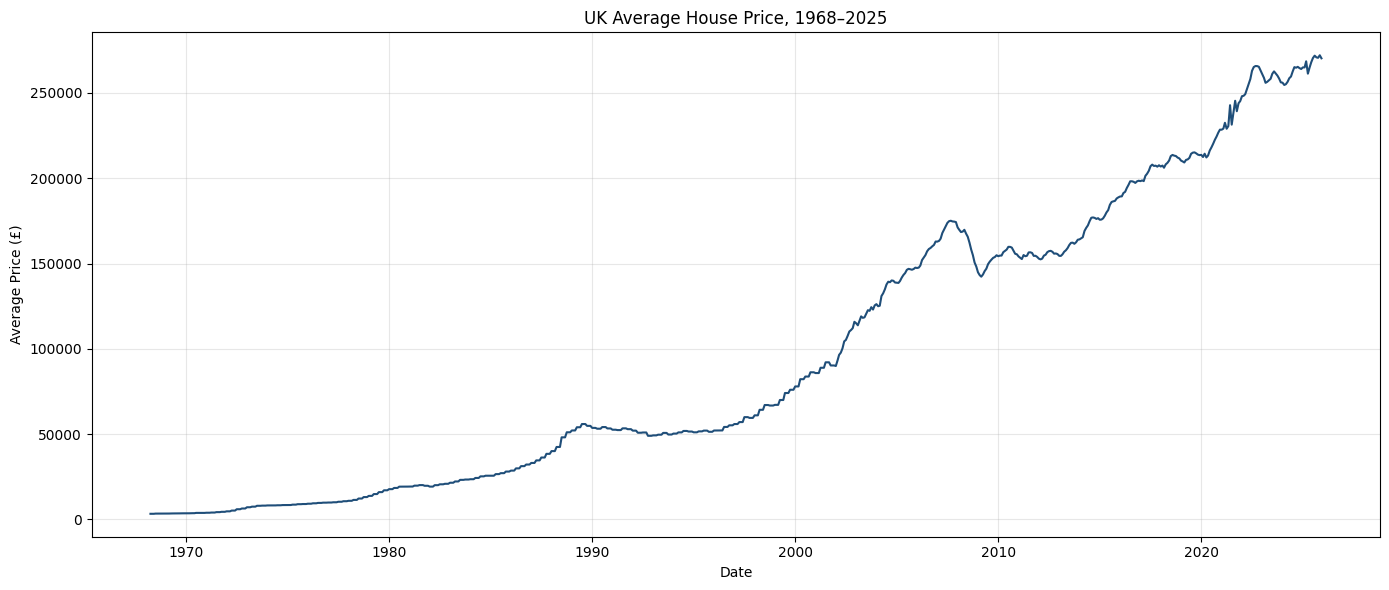

In [78]:
uk = df_clean[df_clean["RegionName"] == "United Kingdom"].sort_values("Date")

plt.figure(figsize=(14, 6))
plt.plot(uk["Date"], uk["AveragePrice"], color="#1f4e79", linewidth=1.5)
plt.title("UK Average House Price, 1968–2025")
plt.xlabel("Date")
plt.ylabel("Average Price (£)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [79]:
peak_row = uk.loc[uk["AveragePrice"].idxmax()]
min_row = uk.loc[uk["AveragePrice"].idxmin()]

print(f"Earliest recorded price: £{uk.iloc[0]['AveragePrice']:,.0f} ({uk.iloc[0]['Date'].date()})")
print(f"Latest recorded price:   £{uk.iloc[-1]['AveragePrice']:,.0f} ({uk.iloc[-1]['Date'].date()})")
print(f"All-time peak:           £{peak_row['AveragePrice']:,.0f} ({peak_row['Date'].date()})")
print(f"Overall growth since 1968: {uk.iloc[-1]['PriceGrowthSinceStart']:,.0f}%")

Earliest recorded price: £3,311 (1968-04-01)
Latest recorded price:   £270,259 (2025-12-01)
All-time peak:           £272,043 (2025-11-01)
Overall growth since 1968: 8,062%


## 4.2 — House prices by region

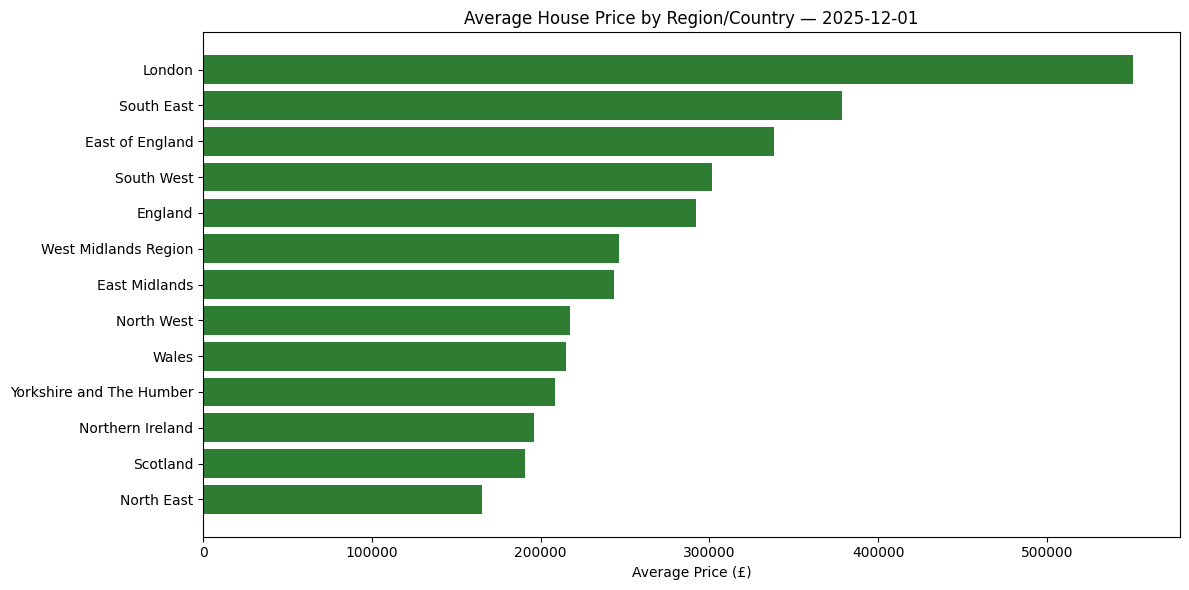

In [80]:
latest_date = df_clean["Date"].max()

regional_latest = df_clean[
    (df_clean["GeoLevel"].isin(["Region", "Country"])) &
    (df_clean["Date"] == latest_date)
][["RegionName", "AveragePrice"]].sort_values("AveragePrice", ascending=False)

plt.figure(figsize=(12, 6))
plt.barh(regional_latest["RegionName"], regional_latest["AveragePrice"], color="#2e7d32")
plt.gca().invert_yaxis()
plt.title(f"Average House Price by Region/Country — {latest_date.date()}")
plt.xlabel("Average Price (£)")
plt.tight_layout()
plt.show()

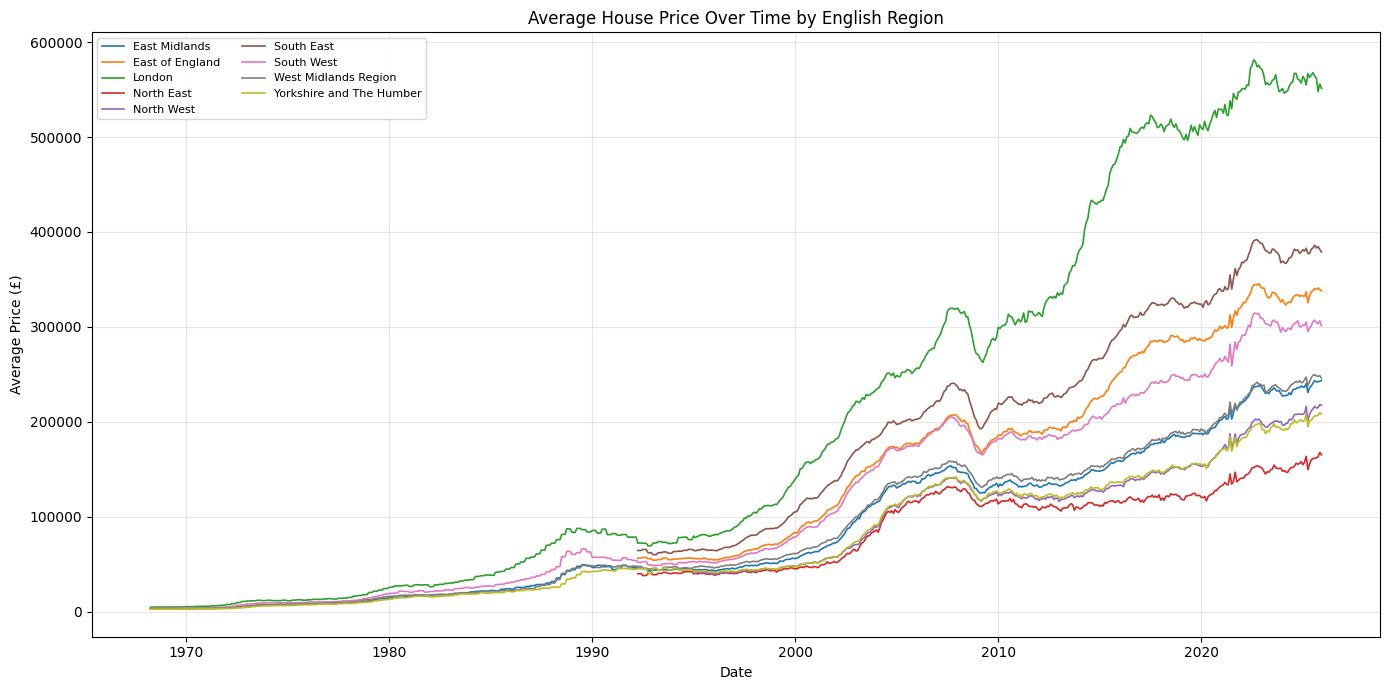

In [81]:
regions_only = df_clean[df_clean["GeoLevel"] == "Region"]

plt.figure(figsize=(14, 7))
for region, group in regions_only.groupby("RegionName"):
    group = group.sort_values("Date")
    plt.plot(group["Date"], group["AveragePrice"], label=region, linewidth=1.2)

plt.title("Average House Price Over Time by English Region")
plt.xlabel("Date")
plt.ylabel("Average Price (£)")
plt.legend(loc="upper left", fontsize=8, ncol=2)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 4.3 — Detached vs semi-detached vs terraced vs flat

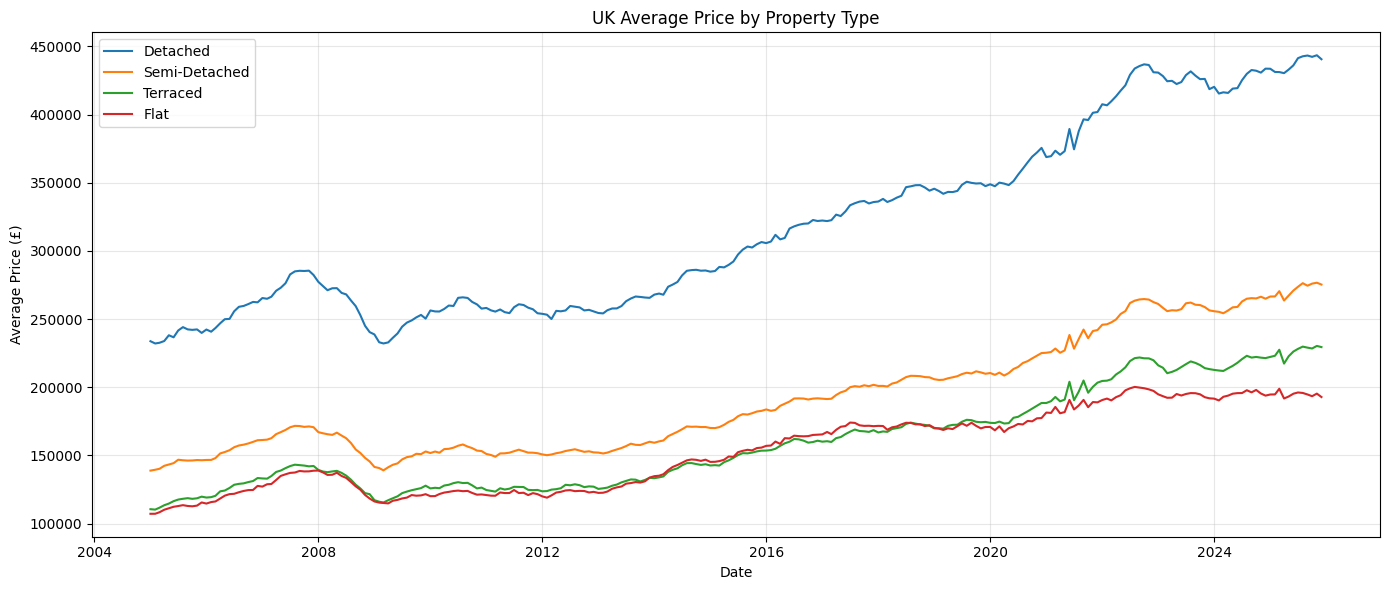

In [82]:
property_types = {
    "Detached": "DetachedPrice",
    "Semi-Detached": "SemiDetachedPrice",
    "Terraced": "TerracedPrice",
    "Flat": "FlatPrice"
}

plt.figure(figsize=(14, 6))
for label, col in property_types.items():
    plt.plot(uk["Date"], uk[col], label=label, linewidth=1.5)

plt.title("UK Average Price by Property Type")
plt.xlabel("Date")
plt.ylabel("Average Price (£)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [83]:
latest_by_type = {
    label: uk.loc[uk[col].notna(), col].iloc[-1]
    for label, col in property_types.items()
}

for label, price in sorted(latest_by_type.items(), key=lambda x: -x[1]):
    print(f"{label:15s} £{price:,.0f}")

Detached        £440,564
Semi-Detached   £275,313
Terraced        £229,449
Flat            £192,826


## 4.4 — Cash vs mortgage purchases

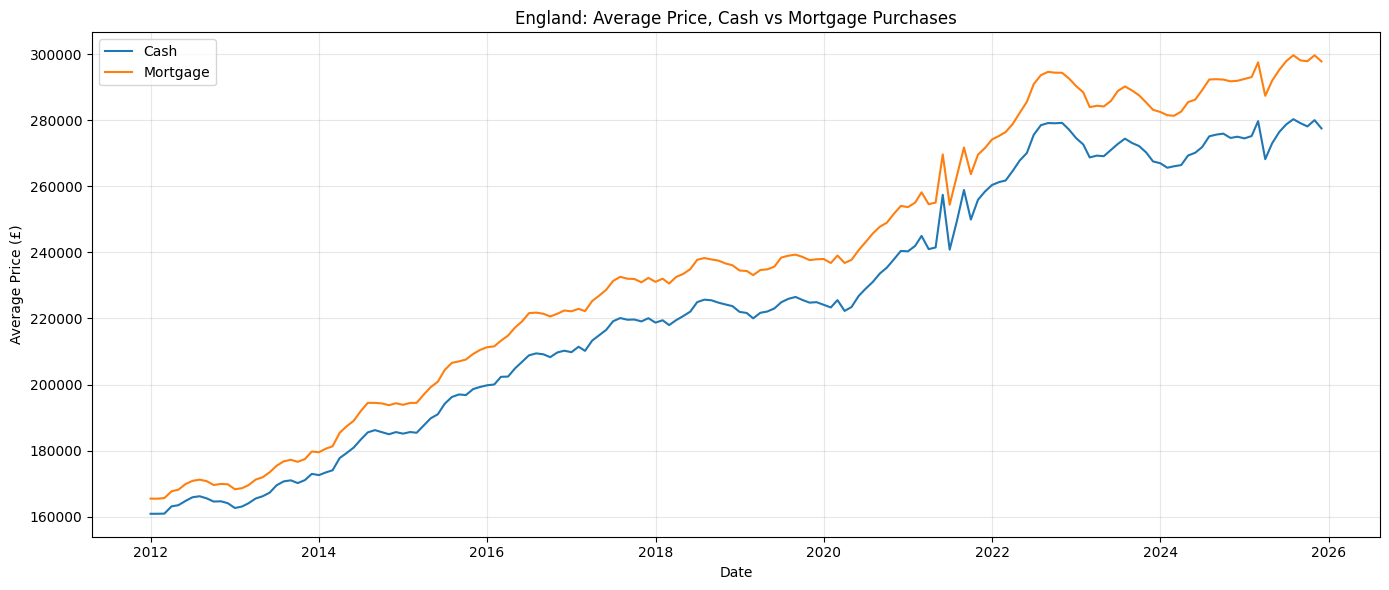

In [84]:
england = df_clean[df_clean["RegionName"] == "England"].sort_values("Date")
buyer_price = england[england["CashPrice"].notna()]

plt.figure(figsize=(14, 6))
plt.plot(buyer_price["Date"], buyer_price["CashPrice"], label="Cash", linewidth=1.5)
plt.plot(buyer_price["Date"], buyer_price["MortgagePrice"], label="Mortgage", linewidth=1.5)
plt.title("England: Average Price, Cash vs Mortgage Purchases")
plt.xlabel("Date")
plt.ylabel("Average Price (£)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

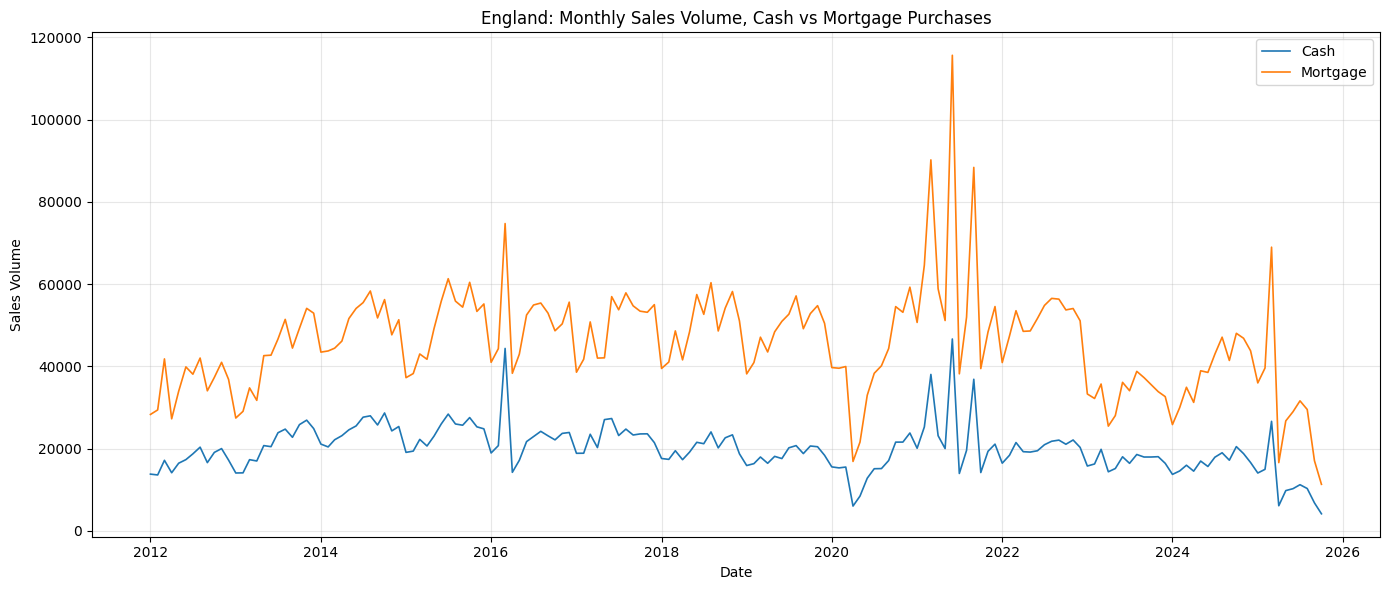

In [85]:
buyer_volume = england[england["CashSalesVolume"].notna()]

plt.figure(figsize=(14, 6))
plt.plot(buyer_volume["Date"], buyer_volume["CashSalesVolume"], label="Cash", linewidth=1.2)
plt.plot(buyer_volume["Date"], buyer_volume["MortgageSalesVolume"], label="Mortgage", linewidth=1.2)
plt.title("England: Monthly Sales Volume, Cash vs Mortgage Purchases")
plt.xlabel("Date")
plt.ylabel("Sales Volume")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 4.5 — First-time buyer prices

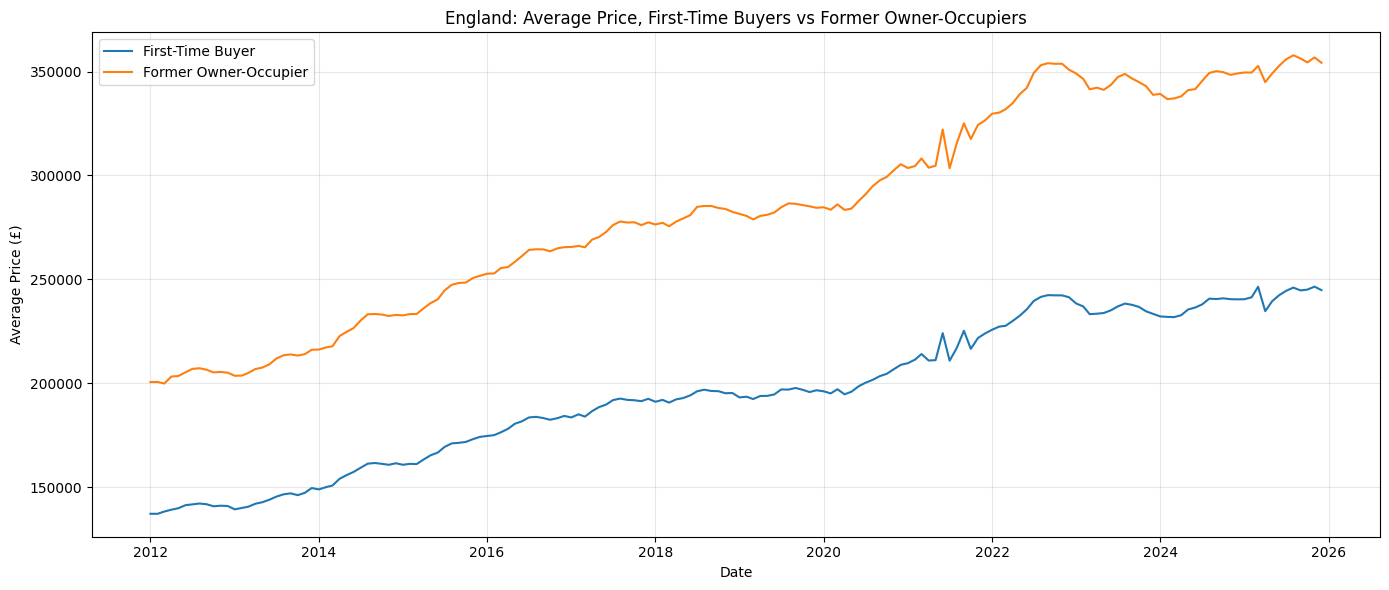

In [86]:
ftb = england[england["FTBPrice"].notna()]

plt.figure(figsize=(14, 6))
plt.plot(ftb["Date"], ftb["FTBPrice"], label="First-Time Buyer", linewidth=1.5)
plt.plot(ftb["Date"], ftb["FOOPrice"], label="Former Owner-Occupier", linewidth=1.5)
plt.title("England: Average Price, First-Time Buyers vs Former Owner-Occupiers")
plt.xlabel("Date")
plt.ylabel("Average Price (£)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [87]:
latest_ftb = ftb.iloc[-1]
gap = latest_ftb["FOOPrice"] - latest_ftb["FTBPrice"]
gap_pct = gap / latest_ftb["FTBPrice"] * 100

print(f"Latest date: {latest_ftb['Date'].date()}")
print(f"First-Time Buyer price:      £{latest_ftb['FTBPrice']:,.0f}")
print(f"Former Owner-Occupier price: £{latest_ftb['FOOPrice']:,.0f}")
print(f"Gap: £{gap:,.0f} ({gap_pct:.1f}% higher for FOO)")

Latest date: 2025-12-01
First-Time Buyer price:      £244,799
Former Owner-Occupier price: £354,250
Gap: £109,451 (44.7% higher for FOO)


## 4.6 — New vs old properties

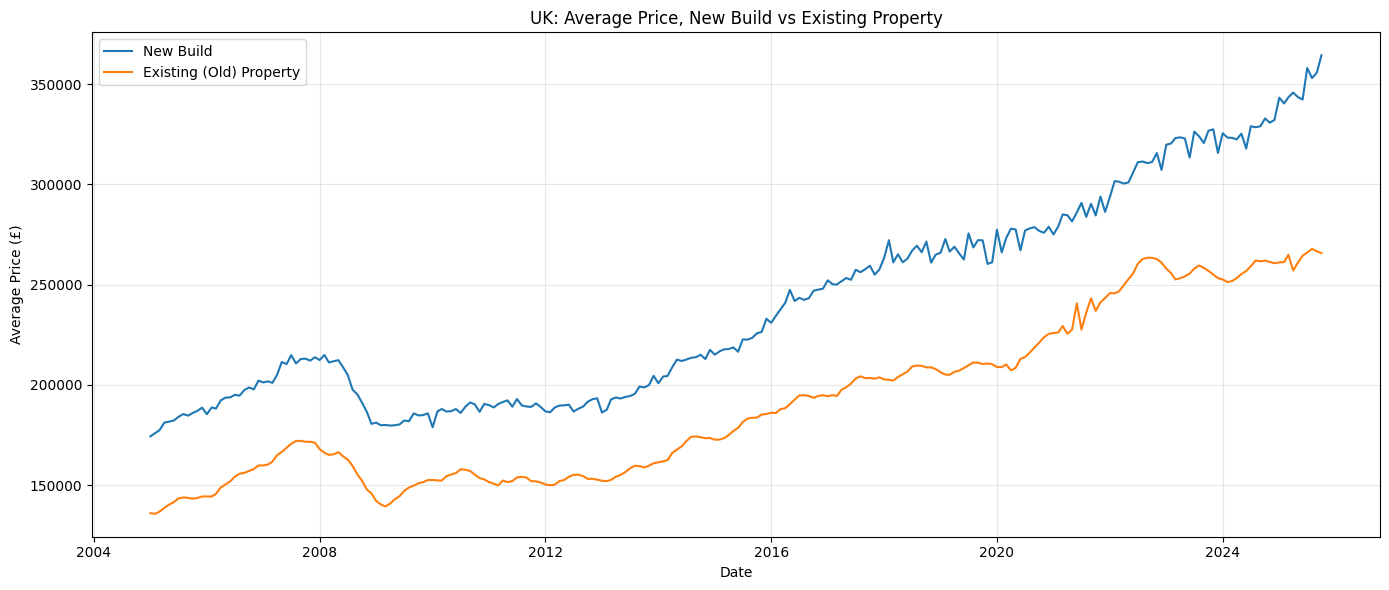

In [88]:
new_old = uk[uk["NewPrice"].notna()]

plt.figure(figsize=(14, 6))
plt.plot(new_old["Date"], new_old["NewPrice"], label="New Build", linewidth=1.5)
plt.plot(new_old["Date"], new_old["OldPrice"], label="Existing (Old) Property", linewidth=1.5)
plt.title("UK: Average Price, New Build vs Existing Property")
plt.xlabel("Date")
plt.ylabel("Average Price (£)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 4.7 — Annual (12-month) price growth

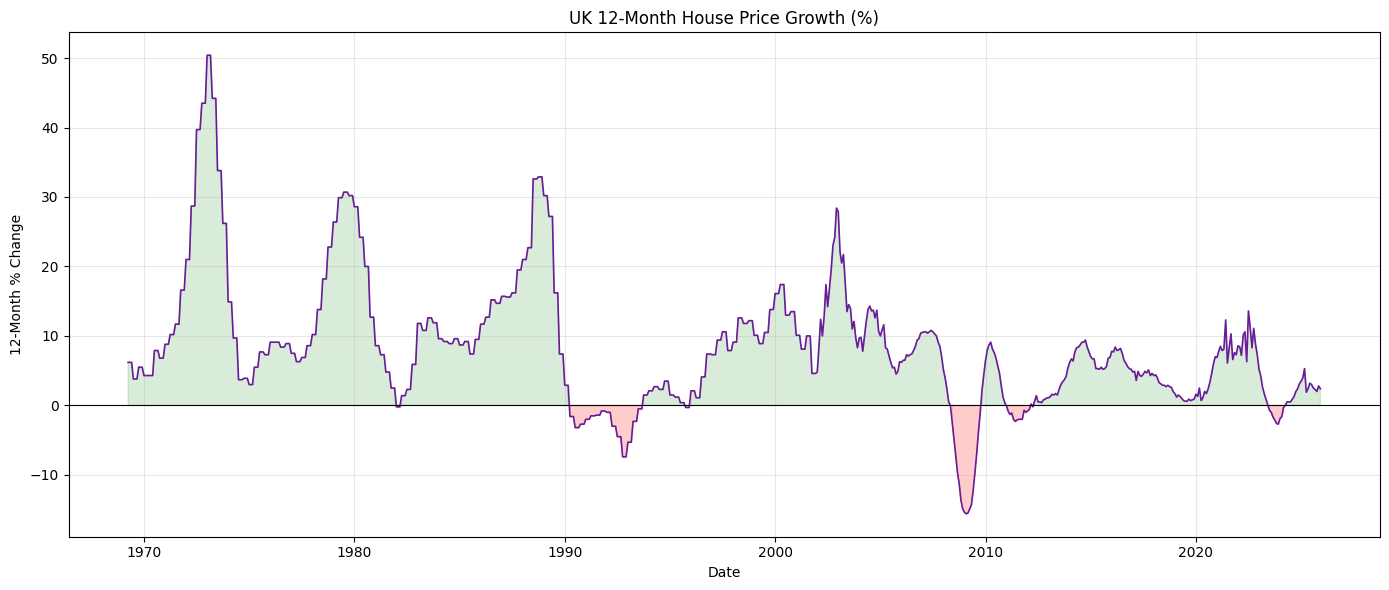

In [89]:
uk_growth = uk[uk["12m%Change"].notna()]

plt.figure(figsize=(14, 6))
plt.plot(uk_growth["Date"], uk_growth["12m%Change"], color="#6a1b9a", linewidth=1.2)
plt.axhline(0, color="black", linewidth=0.8)
plt.fill_between(
    uk_growth["Date"], uk_growth["12m%Change"], 0,
    where=(uk_growth["12m%Change"] < 0), color="red", alpha=0.2
)
plt.fill_between(
    uk_growth["Date"], uk_growth["12m%Change"], 0,
    where=(uk_growth["12m%Change"] >= 0), color="green", alpha=0.15
)
plt.title("UK 12-Month House Price Growth (%)")
plt.xlabel("Date")
plt.ylabel("12-Month % Change")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [90]:
trough = uk_growth.loc[uk_growth["12m%Change"].idxmin()]
peak_growth = uk_growth.loc[uk_growth["12m%Change"].idxmax()]

print(f"Sharpest annual decline: {trough['12m%Change']:.1f}% in {trough['Date'].date()}")
print(f"Fastest annual growth:   {peak_growth['12m%Change']:.1f}% in {peak_growth['Date'].date()}")
print(f"Months with negative annual growth: {(uk_growth['12m%Change'] < 0).sum()} of {len(uk_growth)}")

Sharpest annual decline: -15.6% in 2009-02-01
Fastest annual growth:   50.4% in 1973-01-01
Months with negative annual growth: 89 of 681


## 4.8 — EDA Wrap-Up

Key numbers pulled out of the charts above:

- **UK price growth**: from £3,311 in April 1968 to £270,259 in December 2025 — a **~8,062%** cumulative increase, peaking at £272,043 in November 2025.
- **Regional spread**: the bar chart in 4.2 shows a wide and persistent gap between London/South East and the rest of the UK — worth digging into with `RegionalPriceDiff` in a later section.
- **Property type premium**: Detached (£440,564) > Semi-Detached (£275,313) > Terraced (£229,449) > Flat (£192,826), latest month — Detached costs roughly 2.3x a Flat.
- **First-time buyers vs Former Owner-Occupiers** (England): FTBs pay £244,799 on average vs £354,250 for FOOs — a **44.7%** gap, consistent with FTBs skewing toward smaller/cheaper properties.
- **Annual growth volatility**: 12-month price growth has been negative in 89 of the last 681 months (~13% of the time), with the sharpest annual decline (-15.6%) in Feb 2009 and the fastest annual growth (+50.4%) in Jan 1973.

This gives us a solid base of visual and numeric findings. Next would be **Step 5 — SQL Analysis**, where we translate several of these same questions (top regions by price, property-type comparisons, year-over-year growth) into SQL using `GROUP BY`, `CASE`, CTEs, and window functions (`LAG`, `RANK`, `PARTITION BY`).

# Step 5 — SQL Analysis

The full, standalone version of this analysis lives in **`UK_HPI_SQL_Analysis.sql`** — written in T-SQL against a `UK_HPI` table, meant to be run in SQL Server/Azure SQL exactly as-is (that's the file to link to or paste into a portfolio README).

The cells below run the *same* queries here in the notebook using **DuckDB**, so the results are visible immediately without needing a separate database. DuckDB's SQL is close to T-SQL but not identical — two small dialect differences to note:

- `SELECT TOP N` (T-SQL) → `... LIMIT N` (DuckDB, standard SQL)
- `STDEV()` (T-SQL) → `STDDEV_SAMP()` (DuckDB)

Everything else — `GROUP BY`, `CASE`, CTEs, `LAG()`, `RANK()`, `PARTITION BY`, `FIRST_VALUE()` — is written identically in both files.

In [91]:
import duckdb

# DuckDB can't register pandas' Period dtype (YearMonth), so pass a
# DuckDB-friendly copy with that column cast to string. df_clean itself
# is left untouched.
df_sql = df_clean.copy()
df_sql["YearMonth"] = df_sql["YearMonth"].astype(str)

con = duckdb.connect()
con.register("UK_HPI", df_sql)

print("DuckDB connected. UK_HPI view registered with", len(df_sql), "rows.")

DuckDB connected. UK_HPI view registered with 149085 rows.


## 5.1 — Top 10 areas by average house price (GROUP BY)

In [92]:
con.execute("""
    SELECT
        RegionName,
        AVG(AveragePrice) AS AvgHousePrice
    FROM UK_HPI
    WHERE GeoLevel = 'Local Authority'
    GROUP BY RegionName
    ORDER BY AvgHousePrice DESC
    LIMIT 10
""").df()

,RegionName,AvgHousePrice
0,Kensington and Chelsea,925670.900538
1,City of Westminster,673948.811828
2,Camden,536308.911290
3,Hammersmith and Fulham,524570.408602
4,City of London,498020.346774
5,Richmond upon Thames,475927.626344
6,Wandsworth,453263.583333
7,Elmbridge,441132.685484
8,Islington,427477.663978
9,Inner London,405515.220430


## 5.2 — Average price and growth by GeoLevel and Decade (GROUP BY)

In [93]:
con.execute("""
    SELECT
        GeoLevel,
        Decade,
        COUNT(*) AS Observations,
        AVG(AveragePrice) AS AvgPrice,
        AVG("12m%Change") AS Avg12mChange
    FROM UK_HPI
    GROUP BY GeoLevel, Decade
    ORDER BY GeoLevel, Decade
""").df()

,GeoLevel,Decade,Observations,AvgPrice,Avg12mChange
0,Aggregate,1990,60,55861.066667,6.975000
1,Aggregate,2000,192,140769.187500,7.177222
2,Aggregate,2010,240,187205.779167,3.893333
3,Aggregate,2020,144,260057.833333,3.922222
4,Country,1960,84,3180.250000,4.325000
5,Country,1970,480,7806.431250,16.598750
6,Country,1980,480,24175.287500,10.456250
7,Country,1990,480,44700.160417,3.973750
8,Country,2000,480,111104.608333,10.197083
9,Country,2010,480,143413.500000,2.069583


## 5.3 — Price-band classification (CASE)

In [94]:
con.execute("""
    SELECT
        CASE
            WHEN AveragePrice < 150000 THEN '1. Affordable (<£150k)'
            WHEN AveragePrice >= 150000 AND AveragePrice < 300000 THEN '2. Mid-Range (£150k-£300k)'
            WHEN AveragePrice >= 300000 AND AveragePrice < 600000 THEN '3. Premium (£300k-£600k)'
            ELSE '4. Luxury (£600k+)'
        END AS PriceBand,
        COUNT(*) AS Observations
    FROM UK_HPI
    WHERE GeoLevel = 'Local Authority'
    GROUP BY 1
    ORDER BY PriceBand
""").df()

,PriceBand,Observations
0,1. Affordable (<£150k),65316
1,2. Mid-Range (£150k-£300k),54614
2,3. Premium (£300k-£600k),18163
3,4. Luxury (£600k+),1839


## 5.4 — Year-over-year price growth per region (CTE + LAG + PARTITION BY)

In [95]:
yoy = con.execute("""
    WITH YearlyAvg AS (
        SELECT
            RegionName,
            Year,
            AVG(AveragePrice) AS AvgPrice
        FROM UK_HPI
        WHERE GeoLevel IN ('Region', 'Country')
        GROUP BY RegionName, Year
    )
    SELECT
        RegionName,
        Year,
        AvgPrice,
        LAG(AvgPrice) OVER (PARTITION BY RegionName ORDER BY Year) AS PriorYearPrice,
        ROUND(
            (AvgPrice - LAG(AvgPrice) OVER (PARTITION BY RegionName ORDER BY Year))
            / LAG(AvgPrice) OVER (PARTITION BY RegionName ORDER BY Year) * 100
        , 2) AS YoY_PercentChange
    FROM YearlyAvg
    ORDER BY RegionName, Year
""").df()

yoy.tail(15)

,RegionName,Year,AvgPrice,PriorYearPrice,YoY_PercentChange
640,Yorkshire and The Humber,2011,122764.583333,126262.750000,-2.77
641,Yorkshire and The Humber,2012,121940.000000,122764.583333,-0.67
642,Yorkshire and The Humber,2013,122567.750000,121940.000000,0.51
643,Yorkshire and The Humber,2014,128395.750000,122567.750000,4.75
644,Yorkshire and The Humber,2015,133532.833333,128395.750000,4.00
645,Yorkshire and The Humber,2016,140258.833333,133532.833333,5.04
646,Yorkshire and The Humber,2017,145722.000000,140258.833333,3.90
647,Yorkshire and The Humber,2018,150530.333333,145722.000000,3.30
648,Yorkshire and The Humber,2019,153801.083333,150530.333333,2.17
649,Yorkshire and The Humber,2020,159281.000000,153801.083333,3.56


In [96]:
# Quick look: which region/year had the single largest YoY drop and jump?
print("Largest YoY drop:")
print(yoy.loc[yoy["YoY_PercentChange"].idxmin()])
print()
print("Largest YoY jump:")
print(yoy.loc[yoy["YoY_PercentChange"].idxmax()])

Largest YoY drop:
RegionName           Northern Ireland
Year                             2009
AvgPrice                    133799.25
PriorYearPrice               167045.0
YoY_PercentChange               -19.9
Name: 314, dtype: object

Largest YoY jump:
RegionName           East Midlands
Year                          1973
AvgPrice                    6616.0
PriorYearPrice             4464.75
YoY_PercentChange            48.18
Name: 5, dtype: object


## 5.5 — Top 3 priciest regions per year (CTE + RANK + PARTITION BY)

In [97]:
top3 = con.execute("""
    WITH YearlyAvg AS (
        SELECT
            RegionName,
            Year,
            AVG(AveragePrice) AS AvgPrice
        FROM UK_HPI
        WHERE GeoLevel IN ('Region', 'Country')
        GROUP BY RegionName, Year
    ),
    Ranked AS (
        SELECT
            RegionName,
            Year,
            AvgPrice,
            RANK() OVER (PARTITION BY Year ORDER BY AvgPrice DESC) AS PriceRank
        FROM YearlyAvg
    )
    SELECT * FROM Ranked
    WHERE PriceRank <= 3
    ORDER BY Year, PriceRank
""").df()

top3.tail(15)

,RegionName,Year,AvgPrice,PriceRank
159,London,2021,535453.666667,1
160,South East,2021,348428.166667,2
161,East of England,2021,307257.083333,3
162,London,2022,565955.416667,1
163,South East,2022,381020.250000,2
164,East of England,2022,335998.000000,3
165,London,2023,558023.750000,1
166,South East,2023,379221.500000,2
167,East of England,2023,333809.416667,3
168,London,2024,556103.583333,1


In [98]:
# How many distinct regions have EVER held the #1 spot?
print("Regions that were ever ranked #1:")
print(top3[top3["PriceRank"] == 1]["RegionName"].unique())

Regions that were ever ranked #1:
['London']


## 5.6 — 3-month rolling average price, UK (window function)

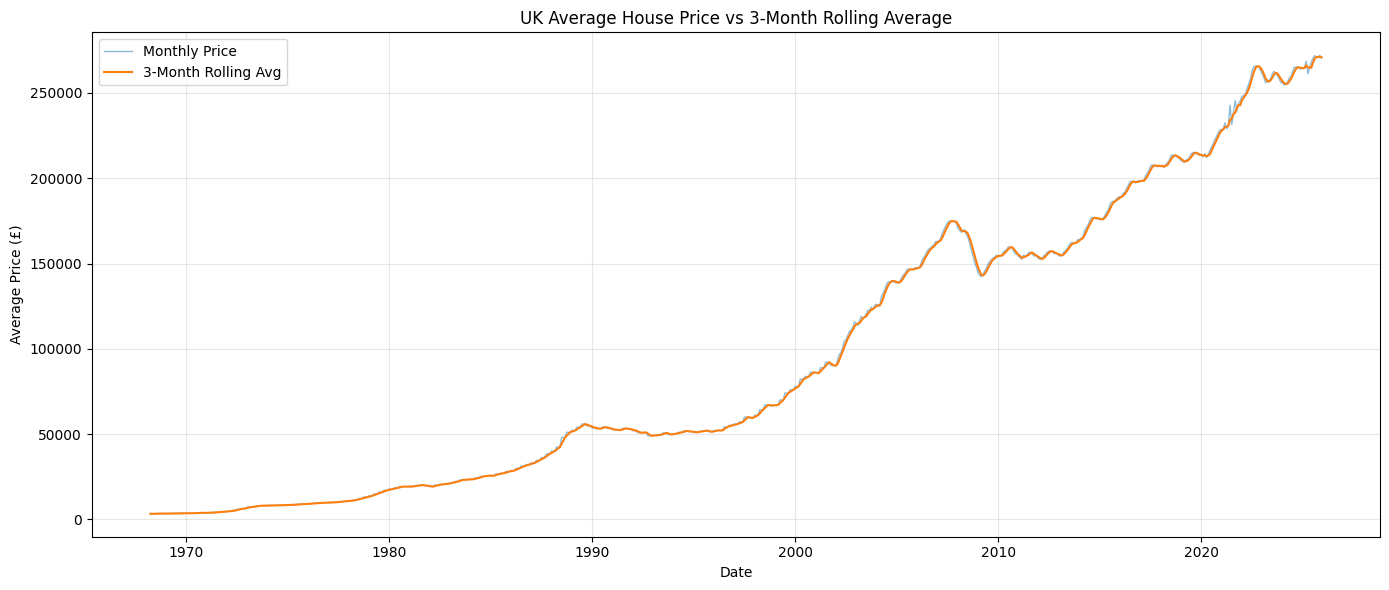

In [99]:
rolling = con.execute("""
    SELECT
        RegionName,
        Date,
        AveragePrice,
        AVG(AveragePrice) OVER (
            PARTITION BY RegionName
            ORDER BY Date
            ROWS BETWEEN 2 PRECEDING AND CURRENT ROW
        ) AS RollingAvg3m
    FROM UK_HPI
    WHERE RegionName = \'United Kingdom\'
    ORDER BY Date
""").df()

plt.figure(figsize=(14, 6))
plt.plot(rolling["Date"], rolling["AveragePrice"], label="Monthly Price", alpha=0.5, linewidth=1)
plt.plot(rolling["Date"], rolling["RollingAvg3m"], label="3-Month Rolling Avg", linewidth=1.5)
plt.title("UK Average House Price vs 3-Month Rolling Average")
plt.xlabel("Date")
plt.ylabel("Average Price (£)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 5.7 — Property-type price gap by region, ranked (CTE + RANK)

In [100]:
con.execute("""
    WITH PropertyGap AS (
        SELECT
            RegionName,
            AVG(DetachedPrice) AS AvgDetached,
            AVG(FlatPrice) AS AvgFlat
        FROM UK_HPI
        WHERE GeoLevel IN ('Region', 'Country')
          AND DetachedPrice IS NOT NULL
          AND FlatPrice IS NOT NULL
        GROUP BY RegionName
    )
    SELECT
        RegionName,
        AvgDetached,
        AvgFlat,
        AvgDetached - AvgFlat AS DetachedFlatGap,
        ROUND((AvgDetached - AvgFlat) / AvgFlat * 100, 1) AS DetachedFlatGapPercent,
        RANK() OVER (ORDER BY AvgDetached - AvgFlat DESC) AS GapRank
    FROM PropertyGap
    ORDER BY GapRank
""").df()

,RegionName,AvgDetached,AvgFlat,DetachedFlatGap,DetachedFlatGapPercent,GapRank
0,London,661950.110215,284039.588710,377910.521505,133.0,1
1,South East,410946.637097,142593.327957,268353.309140,188.2,2
2,South West,301606.911290,117655.639785,183951.271505,156.3,3
3,East of England,307503.317204,127644.879032,179858.438172,140.9,4
4,West Midlands Region,243007.190860,90633.577957,152373.612903,168.1,5
5,Scotland,249290.143939,103208.715909,146081.428030,141.5,6
6,England,276349.422043,143197.290323,133152.131720,93.0,7
7,North West,216928.650538,84767.301075,132161.349462,155.9,8
8,East Midlands,206394.620968,81226.163978,125168.456989,154.1,9
9,Yorkshire and The Humber,202004.094086,84206.247312,117797.846774,139.9,10


## 5.8 — Cash vs. Mortgage buyers, by country (CASE + GROUP BY)

In [101]:
con.execute("""
    SELECT
        RegionName,
        AVG(CashPrice) AS AvgCashPrice,
        AVG(MortgagePrice) AS AvgMortgagePrice,
        CASE
            WHEN AVG(CashPrice) > AVG(MortgagePrice) THEN 'Cash buyers pay more'
            WHEN AVG(CashPrice) < AVG(MortgagePrice) THEN 'Mortgage buyers pay more'
            ELSE 'No meaningful difference'
        END AS Comparison
    FROM UK_HPI
    WHERE GeoLevel = 'Country'
      AND CashPrice IS NOT NULL
    GROUP BY RegionName
    ORDER BY RegionName
""").df()

,RegionName,AvgCashPrice,AvgMortgagePrice,Comparison
0,England,224348.982143,236598.261905,Mortgage buyers pay more
1,Scotland,140026.500000,155412.904762,Mortgage buyers pay more
2,Wales,161275.369048,159105.803571,Cash buyers pay more


## 5.9 — Cumulative growth since first record, UK (FIRST_VALUE window function)

In [102]:
growth_check = con.execute("""
    SELECT
        RegionName,
        Date,
        AveragePrice,
        FIRST_VALUE(AveragePrice) OVER (
            PARTITION BY RegionName ORDER BY Date
        ) AS FirstRecordedPrice,
        ROUND(
            (AveragePrice / FIRST_VALUE(AveragePrice) OVER (
                PARTITION BY RegionName ORDER BY Date
            ) - 1) * 100
        , 1) AS GrowthSinceStartPercent
    FROM UK_HPI
    WHERE RegionName = \'United Kingdom\'
    ORDER BY Date
""").df()

# Cross-check against the pandas-derived PriceGrowthSinceStart from Step 3.36
uk_check = df_clean[df_clean["RegionName"] == "United Kingdom"].sort_values("Date")
print("SQL FIRST_VALUE result (latest row):  ", growth_check["GrowthSinceStartPercent"].iloc[-1], "%")
print("pandas PriceGrowthSinceStart (latest):", round(uk_check["PriceGrowthSinceStart"].iloc[-1], 1), "%")

SQL FIRST_VALUE result (latest row):   8062.5 %
pandas PriceGrowthSinceStart (latest): 8062.5 %


## 5.10 — Most volatile regions (GROUP BY + STDDEV)

In [103]:
con.execute("""
    SELECT
        RegionName,
        AVG("12m%Change") AS AvgAnnualGrowth,
        STDDEV_SAMP("12m%Change") AS VolatilityStdDev
    FROM UK_HPI
    WHERE GeoLevel IN ('Region', 'Country')
      AND "12m%Change" IS NOT NULL
    GROUP BY RegionName
    ORDER BY VolatilityStdDev DESC
""").df()

,RegionName,AvgAnnualGrowth,VolatilityStdDev
0,South West,8.802790,12.007607
1,Northern Ireland,7.943025,11.917609
2,London,9.270191,10.992189
3,East Midlands,8.535389,10.864424
4,West Midlands Region,8.398825,10.818859
5,Yorkshire and The Humber,8.482379,10.636098
6,Wales,8.330103,10.328981
7,England,8.646109,10.110393
8,North East,4.702545,8.514321
9,Scotland,7.940088,8.146211


## 5.11 — Step 5 Wrap-Up

The pandas-derived `PriceGrowthSinceStart` column (built in Step 3.36) matches the `FIRST_VALUE()` window-function result computed independently in SQL (5.9) — a good consistency check between the two approaches.

Both the standalone `UK_HPI_SQL_Analysis.sql` file and this notebook section cover the full range of requested SQL techniques: `GROUP BY`, `CASE`, CTEs, `LAG()`, `RANK()`, `PARTITION BY`, `FIRST_VALUE()`, and year-over-year calculations.

That completes Steps 1–5 of the project. A natural Step 6 from here would be a Power BI (or similar) dashboard built on top of `UK_HPI_cleaned.csv`, pulling together the regional, property-type, and buyer-type comparisons into an interactive view.